In [3]:
import pandas as pd

df = pd.read_csv("email_dataset_classification.csv", engine='python', on_bad_lines='warn')

df.to_csv(
    "cleaned_email_dataset.csv",
    index=False
)

print("File saved successfully!")

/tmp/ipykernel_3684/1110833805.py:3: ParserWarning: Skipping line 3450: field larger than field limit (131072)

  df = pd.read_csv("email_dataset_classification.csv", engine='python', on_bad_lines='warn')
/tmp/ipykernel_3684/1110833805.py:3: ParserWarning: Skipping line 6207: field larger than field limit (131072)

  df = pd.read_csv("email_dataset_classification.csv", engine='python', on_bad_lines='warn')
/tmp/ipykernel_3684/1110833805.py:3: ParserWarning: Skipping line 6931: unexpected end of data

  df = pd.read_csv("email_dataset_classification.csv", engine='python', on_bad_lines='warn')


File saved successfully!


In [4]:
# ============================================================
# IMPORT REQUIRED LIBRARIES
# ============================================================

import pandas as pd
import numpy as np

import re
import string
import nltk

from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB

from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    f1_score
)

import matplotlib.pyplot as plt
import seaborn as sns

import pickle

In [5]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [6]:
df = pd.read_csv(
    "cleaned_email_dataset.csv",
    engine='python'
)

In [7]:
df = df[df['label'].isin(['0', '1', 0, 1])]

df['label'] = df['label'].astype(int)

In [8]:
df.dropna(inplace=True)

In [9]:
stop_words = set(stopwords.words('english'))

In [10]:
def preprocess_text(text):

    # convert to lowercase
    text = text.lower()

    # remove urls
    text = re.sub(r'http\S+', '', text)

    # remove numbers
    text = re.sub(r'\d+', '', text)

    # remove punctuation
    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    # split words
    words = text.split()

    # remove stopwords
    words = [
        word for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [11]:
df['cleaned_message'] = df['message'].astype(str).apply(preprocess_text)

In [12]:
X = df['cleaned_message']

y = df['label']

In [13]:
tfidf = TfidfVectorizer(
    max_features=5000
)

X_tfidf = tfidf.fit_transform(X)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

MultinomialNB()

In [16]:
y_pred_nb = nb_model.predict(X_test)

In [17]:
nb_accuracy = accuracy_score(
    y_test,
    y_pred_nb
)

nb_f1 = f1_score(
    y_test,
    y_pred_nb
)

print("Naive Bayes Accuracy:", nb_accuracy)

print("Naive Bayes F1 Score:", nb_f1)

Naive Bayes Accuracy: 0.9264069264069265
Naive Bayes F1 Score: 0.8702290076335878


In [18]:
print(classification_report(
    y_test,
    y_pred_nb
))

              precision    recall  f1-score   support

           0       0.93      0.97      0.95       968
           1       0.93      0.82      0.87       418

    accuracy                           0.93      1386
   macro avg       0.93      0.90      0.91      1386
weighted avg       0.93      0.93      0.92      1386



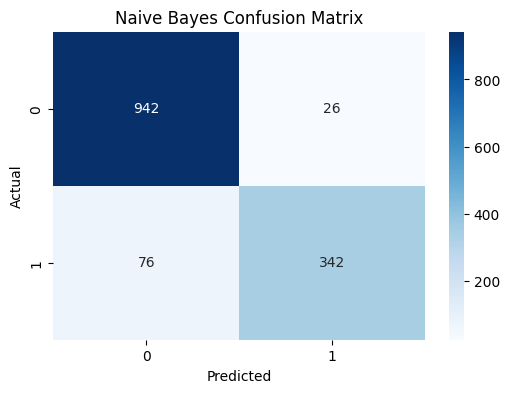

In [19]:
cm_nb = confusion_matrix(
    y_test,
    y_pred_nb
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Naive Bayes Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [23]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    class_weight='balanced'
)

svm_model.fit(X_train, y_train)

print("SVM training completed!")

SVM training completed!


In [24]:
y_pred_svm = svm_model.predict(X_test)

In [ ]:
svm_accuracy = accuracy_score(
    y_test,
    y_pred_svm
)

svm_f1 = f1_score(
    y_test,
    y_pred_svm
)

print("SVM Accuracy:", svm_accuracy)

print("SVM F1 Score:", svm_f1)

In [25]:
svm_accuracy = accuracy_score(
    y_test,
    y_pred_svm
)

svm_f1 = f1_score(
    y_test,
    y_pred_svm
)

print("SVM Accuracy:", svm_accuracy)

print("SVM F1 Score:", svm_f1)

SVM Accuracy: 0.943001443001443
SVM F1 Score: 0.9044740024183797


In [26]:
print(classification_report(
    y_test,
    y_pred_svm
))

              precision    recall  f1-score   support

           0       0.95      0.96      0.96       968
           1       0.91      0.89      0.90       418

    accuracy                           0.94      1386
   macro avg       0.93      0.93      0.93      1386
weighted avg       0.94      0.94      0.94      1386



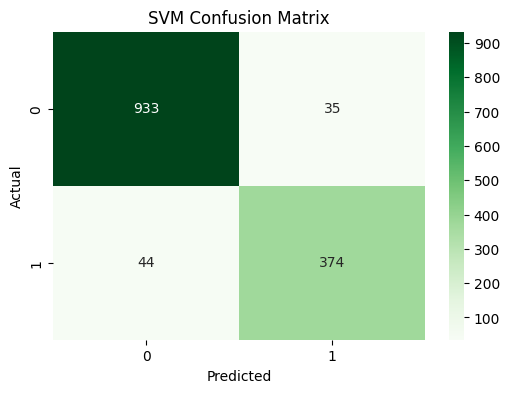

In [27]:
cm_svm = confusion_matrix(
    y_test,
    y_pred_svm
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("SVM Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [28]:
comparison_df = pd.DataFrame({

    'Model': ['Naive Bayes', 'SVM'],

    'Accuracy': [
        nb_accuracy,
        svm_accuracy
    ],

    'F1 Score': [
        nb_f1,
        svm_f1
    ]
})

comparison_df

,Model,Accuracy,F1 Score
0,Naive Bayes,0.926407,0.870229
1,SVM,0.943001,0.904474


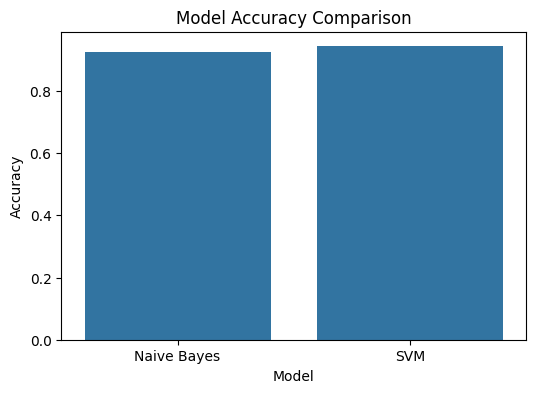

In [29]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=comparison_df,
    x='Model',
    y='Accuracy'
)

plt.title("Model Accuracy Comparison")

plt.show()

In [45]:
import pickle

pickle.dump(
    svm_model,
    open("spam_classifier_model.pkl", "wb")
)

pickle.dump(
    tfidf,
    open("tfidf_vectorizer.pkl", "wb")
)

print("Updated model saved successfully!")

Updated model saved successfully!


In [31]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    f1_score
)

import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.text import Tokenizer

from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import EarlyStopping

In [32]:
df = pd.read_csv("cleaned_email_dataset.csv")

In [33]:
df = df[df['label'].isin(['0', '1', 0, 1])]

df['label'] = df['label'].astype(int)

In [34]:
df.dropna(inplace=True)

In [35]:
X = df['message'].astype(str)

y = df['label']

In [36]:
max_words = 10000

tokenizer = Tokenizer(
    num_words=max_words
)

tokenizer.fit_on_texts(X)

In [37]:
X_sequences = tokenizer.texts_to_sequences(X)

In [38]:
max_len = 200

X_padded = pad_sequences(
    X_sequences,
    maxlen=max_len
)

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X_padded,
    y,
    test_size=0.2,
    random_state=42
)

In [40]:
model = Sequential()

model.add(
    Embedding(
        input_dim=max_words,
        output_dim=128,
        input_length=max_len
    )
)

model.add(
    LSTM(64)
)

model.add(
    Dropout(0.5)
)

model.add(
    Dense(1, activation='sigmoid')
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [41]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [42]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [43]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2
)

In [44]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/5
70/70 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.8010 - loss: 0.4349 - val_accuracy: 0.9125 - val_loss: 0.2440
Epoch 2/5
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9528 - loss: 0.1431 - val_accuracy: 0.9468 - val_loss: 0.1389
Epoch 3/5
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9851 - loss: 0.0561 - val_accuracy: 0.9540 - val_loss: 0.1442
Epoch 4/5
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9903 - loss: 0.0374 - val_accuracy: 0.9477 - val_loss: 0.1513


In [ ]:
y_pred_prob = model.predict(X_test)

y_pred = (y_pred_prob > 0.5).astype(int)

In [ ]:
lstm_accuracy = accuracy_score(
    y_test,
    y_pred
)

lstm_f1 = f1_score(
    y_test,
    y_pred
)

print("LSTM Accuracy:", lstm_accuracy)

print("LSTM F1 Score:", lstm_f1)

In [ ]:
print(classification_report(
    y_test,
    y_pred
))

In [ ]:
cm_lstm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_lstm,
    annot=True,
    fmt='d',
    cmap='Purples'
)

plt.title("LSTM Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [ ]:
plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend(['Train', 'Validation'])

plt.show()

In [ ]:
plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.title("Model Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend(['Train', 'Validation'])

plt.show()

In [ ]:
model.save("lstm_spam_classifier.h5")

print("LSTM model saved successfully!")

In [46]:
from google.colab import files

files.download("spam_classifier_model.pkl")

files.download("tfidf_vectorizer.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>